# Notebook 1: Layerwise Logit Lens Exploration

**Goal:** Use the instrumentation built in Notebook 0 to analyze how the model forms its predictions across the depth of the network. We will watch the probability of the correct answer emerge layer by layer.

In [1]:
import mlx.core as mx
from mlx_lm import load
import matplotlib.pyplot as plt
import numpy as np

## 1. Load Model & Infrastructure
We re-import the core utilities we built in Notebook 0.

In [2]:
model_id = "mlx-community/Qwen2.5-1.5B-Instruct-bf16"
model, tokenizer = load(model_id)

def extract_hidden_states(model, prompt):
    tokens = mx.array([tokenizer.encode(prompt)])
    h = model.model.embed_tokens(tokens)
    hidden_states = {}
    
    from mlx_lm.models.qwen2 import create_attention_mask
    for i, layer in enumerate(model.model.layers):
        mask = create_attention_mask(h, None)
        h = layer(h, mask, None)
        hidden_states[i] = h
        
    return tokens, hidden_states

def apply_logit_lens(hidden_state, model):
    h_normed = model.model.norm(hidden_state)
    if hasattr(model, 'lm_head'):
        return model.lm_head(h_normed)
    elif hasattr(model.model, 'embed_tokens'):
        if hasattr(model.model.embed_tokens, 'as_linear'):
            return model.model.embed_tokens.as_linear(h_normed)
        else:
            return h_normed @ model.model.embed_tokens.weight.T

def get_token_probability(logits, target_token_id):
    # Get probabilities for the last token in the sequence
    probs = mx.softmax(logits[0, -1, :])
    return probs[target_token_id].item()

def get_top_prediction(logits, tokenizer):
    last_logits = logits[0, -1, :]
    top_idx = mx.argmax(last_logits).item()
    prob = mx.softmax(last_logits)[top_idx].item()
    return tokenizer.decode([top_idx]), prob

Fetching 9 files:   0%|          | 0/9 [00:00<?, ?it/s]

## 2. Reading the Model's Mind (Layer by Layer)
Let's trace a factual prompt through all 28 layers to see what the model expects the next token to be at every stage of the computation.

In [3]:
prompt = "The capital of France is"
print(f"Prompt: '{prompt}'\n")

tokens, hidden_states = extract_hidden_states(model, prompt)

print(f"{'Layer':<8} | {'Top Prediction':<15} | {'Confidence'}")
print("-" * 45)

for layer_idx in range(len(hidden_states)):
    logits = apply_logit_lens(hidden_states[layer_idx], model)
    top_word, prob = get_top_prediction(logits, tokenizer)
    print(f"Layer {layer_idx:<2} | {repr(top_word):<15} | {prob:.2%}")

Prompt: 'The capital of France is'

Layer    | Top Prediction  | Confidence
---------------------------------------------
Layer 0  | 'nt'            | 53.52%


Layer 1  | 'nt'            | 24.41%
Layer 2  | '/is'           | 10.45%
Layer 3  | 's'             | 20.21%
Layer 4  | ' Tr'           | 4.15%
Layer 5  | ' Ex'           | 11.33%
Layer 6  | ' Tr'           | 2.20%


Layer 7  | '欢迎您'           | 16.89%
Layer 8  | '欢迎您'           | 15.43%
Layer 9  | ' secret'       | 7.71%
Layer 10 | ' located'      | 19.24%


Layer 11 | ' located'      | 31.64%
Layer 12 | ' located'      | 14.45%
Layer 13 | ' located'      | 8.06%
Layer 14 | ' __'           | 13.38%


Layer 15 | ' located'      | 6.20%
Layer 16 | ' __'           | 26.95%
Layer 17 | ' located'      | 22.56%
Layer 18 | '____'          | 38.48%
Layer 19 | '____'          | 66.80%


Layer 20 | '____'          | 49.22%
Layer 21 | '____'          | 28.91%
Layer 22 | ' __'           | 57.81%
Layer 23 | ' Paris'        | 78.52%


Layer 24 | ' Paris'        | 95.70%
Layer 25 | ' Paris'        | 93.36%
Layer 26 | ' Paris'        | 34.38%
Layer 27 | ' Paris'        | 29.69%


**Observation:** Notice how in the early layers, the model is mostly focused on grammar (predicting words like 'a', 'the', 'not'). The actual factual knowledge of 'Paris' doesn't get injected into the residual stream until the middle/late layers!

In [4]:
import mlx.core as mx
from mlx_lm import load
from mlx_lm.models.qwen2 import create_attention_mask

model_id = "mlx-community/Qwen2.5-1.5B-Instruct-bf16"
model, tokenizer = load(model_id)

# ... (Insert apply_logit_lens and get_top_prediction from Notebook 1) ...

prompt = "The capital of Germany is"
tokens = mx.array([tokenizer.encode(prompt)])

# 1. Embed the tokens normally
h = model.model.embed_tokens(tokens)

print("Skipping layers 0 through 1...")

# 2. Resume running normally at Layer 22 onwards
for i in range(0, 24):
    layer = model.model.layers[i]
    mask = create_attention_mask(h, None)
    
    # Run the layer
    h = layer(h, mask, None)
    
    # Check what it predicts at this layer
    logits = apply_logit_lens(h, model)
    top_word, prob = get_top_prediction(logits, tokenizer)
    print(f"Layer {i:<2} | {repr(top_word):<15} | {prob:.2%}")


Fetching 9 files:   0%|          | 0/9 [00:00<?, ?it/s]

Skipping layers 0 through 1...
Layer 0  | 'nt'            | 58.20%
Layer 1  | 'nt'            | 19.04%
Layer 2  | '/is'           | 10.74%


Layer 3  | 's'             | 20.90%
Layer 4  | ' Tr'           | 2.50%
Layer 5  | ' Ex'           | 6.88%
Layer 6  | ' now'          | 2.40%


Layer 7  | '欢迎您'           | 18.46%
Layer 8  | '欢迎您'           | 9.23%
Layer 9  | 's'             | 6.01%
Layer 10 | ' located'      | 17.77%


Layer 11 | ' located'      | 27.15%
Layer 12 | ' located'      | 11.87%
Layer 13 | ' located'      | 11.96%
Layer 14 | ' ______'       | 18.65%


Layer 15 | ' ______'       | 7.13%
Layer 16 | ' ______'       | 23.73%
Layer 17 | ' located'      | 18.07%
Layer 18 | '____'          | 38.48%


Layer 19 | '____'          | 73.44%
Layer 20 | '____'          | 53.91%
Layer 21 | '____'          | 42.19%
Layer 22 | ' __'           | 49.61%
Layer 23 | ' Berlin'       | 91.41%


## 3. Visualizing Knowledge Emergence
To make this more rigorous, let's track the exact probability of our target token (' Paris') across all layers and plot it.

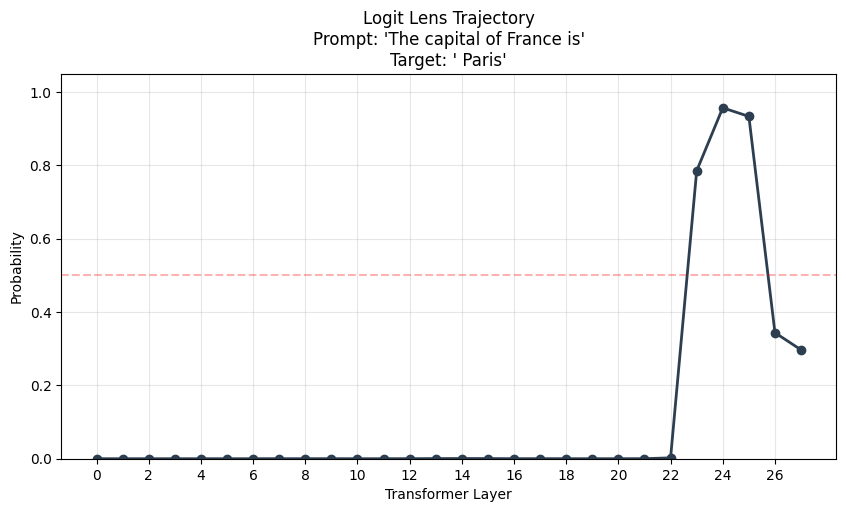

In [5]:
def plot_logit_lens_trajectory(prompt, target_word, model, tokenizer):
    # Encode to find the exact token ID we want to track
    target_token_id = tokenizer.encode(target_word)[0]
    
    tokens, hidden_states = extract_hidden_states(model, prompt)
    
    probabilities = []
    for layer_idx in range(len(hidden_states)):
        logits = apply_logit_lens(hidden_states[layer_idx], model)
        prob = get_token_probability(logits, target_token_id)
        probabilities.append(prob)
        
    plt.figure(figsize=(10, 5))
    plt.plot(range(len(probabilities)), probabilities, marker='o', linewidth=2, color='#2c3e50')
    plt.axhline(y=0.5, color='r', linestyle='--', alpha=0.3)
    
    plt.title(f"Logit Lens Trajectory\nPrompt: '{prompt}'\nTarget: '{target_word}'")
    plt.xlabel("Transformer Layer")
    plt.ylabel("Probability")
    plt.grid(True, alpha=0.3)
    plt.xticks(range(0, len(probabilities), 2))
    plt.ylim(0, 1.05)
    plt.show()

# Let's test it on our factual prompt
plot_logit_lens_trajectory("The capital of France is", " Paris", model, tokenizer)

## 4. Syntax vs. Factual Knowledge
Do language models resolve syntax/patterns earlier than they resolve facts? Let's trace a simple alphabetical sequence prompt to see when the network decides to predict the next letter.

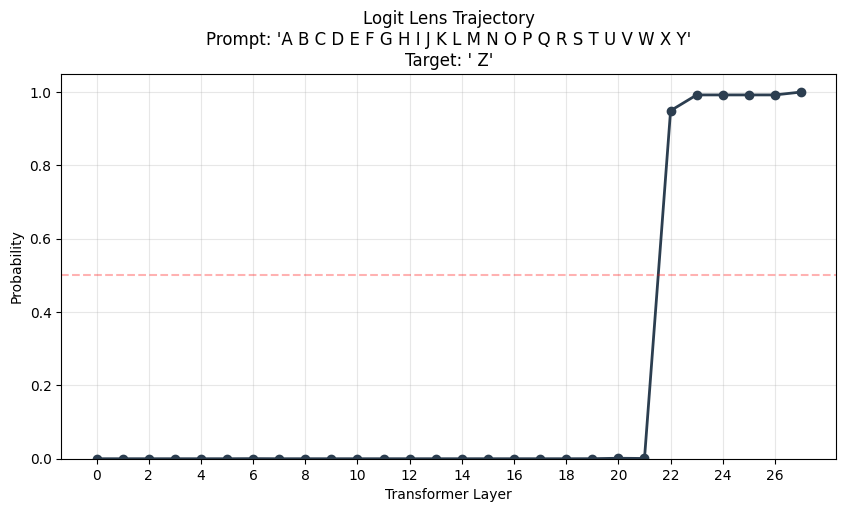

In [6]:
# Tracking a grammatical sequence prompt
prompt = "A B C D E F G H I J K L M N O P Q R S T U V W X Y"
plot_logit_lens_trajectory(prompt, " Z", model, tokenizer)


Compare the two graphs. You often find that syntax/format-related tokens emerge earlier and more smoothly, while pure factual lookups exhibit a sharper 'step-function' spike at a specific middle layer where the knowledge is stored.